In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
import pandas as pd
import numpy as np
HERE = Path().resolve()
PROJECT_ROOT = next(p for p in [HERE, *HERE.parents] if (p / "src").exists())
sys.path.insert(0, str(PROJECT_ROOT))


from src.io.obd_loader import load_obd_csv, require_columns
from src.io.timebase import add_elapsed_time
from src.physics.kinematics import add_speed_ms, add_acceleration
from src.physics.longitudinal import VehicleParams, add_longitudinal_forces
from src.physics.power_energy import add_power_terms, add_energy_terms
#from src.common.units import convert_mdot_air_to_kgs

In [2]:
df1 = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-05_Seat_Leon_RT_S_Stau.csv")
df2 = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-05_Seat_Leon_S_KA_Normal.csv")
df3 = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-06_Seat_Leon_KA_KA_Normal.csv")

df1copy = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-05_Seat_Leon_RT_S_Stau.csv")
df2copy = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-05_Seat_Leon_S_KA_Normal.csv")
df3copy = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-06_Seat_Leon_KA_KA_Normal.csv")

require_columns(df1, ["time", "speed_kmh", "engine_rpm"])
require_columns(df2, ["time", "speed_kmh", "engine_rpm"])
require_columns(df3, ["time", "speed_kmh", "engine_rpm"])




df1 = add_elapsed_time(df1)
df1 = add_speed_ms(df1)
df1 = add_acceleration(df1)

df2 = add_elapsed_time(df2)
df2 = add_speed_ms(df2)
df2 = add_acceleration(df2)

df3 = add_elapsed_time(df3)
df3 = add_speed_ms(df3)
df3 = add_acceleration(df3)




params = VehicleParams(
    mass_kg=1300, Cd=0.3, area_m2=2.2, crr=0.012,
    tyre_radius_m=0.318, rho_air=1.17
)




df1 = add_longitudinal_forces(df1, params, grade_rad=0.0)
df1 = add_power_terms(df1)
df1 = add_energy_terms(df1)

df2 = add_longitudinal_forces(df2, params, grade_rad=0.0)
df2 = add_power_terms(df2)
df2 = add_energy_terms(df2)

df3 = add_longitudinal_forces(df3, params, grade_rad=0.0)
df3 = add_power_terms(df3)
df3 = add_energy_terms(df3)
#df = convert_mdot_air_to_kgs(df)

#print(df)

In [3]:
AFR = 14.7
LHV = 43e6

In [4]:
df1["Air Flow Rate from Mass Flow Sensor [kg/s]"] = df1["Air Flow Rate from Mass Flow Sensor [g/s]"] / 100 
df1["mdot_fuel"] = df1["Air Flow Rate from Mass Flow Sensor [kg/s]"]  / AFR
#df1["mdot_fuel"].head(100)

df2["Air Flow Rate from Mass Flow Sensor [kg/s]"] = df2["Air Flow Rate from Mass Flow Sensor [g/s]"] / 100 
df2["mdot_fuel"] = df2["Air Flow Rate from Mass Flow Sensor [kg/s]"]  / AFR
#df2["mdot_fuel"].head(100)

df3["Air Flow Rate from Mass Flow Sensor [kg/s]"] = df3["Air Flow Rate from Mass Flow Sensor [g/s]"] / 100 
df3["mdot_fuel"] = df3["Air Flow Rate from Mass Flow Sensor [kg/s]"]  / AFR
#df["mdot_fuel"].head(100)

In [5]:
df1["Pfuel"]  = df1["mdot_fuel"] * LHV
df2["Pfuel"]  = df2["mdot_fuel"] * LHV
df3["Pfuel"]  = df3["mdot_fuel"] * LHV

In [6]:
df1["chemical_efficiency"] = df1["P_drive_W"] / df1["Pfuel"]
df2["chemical_efficiency"] = df2["P_drive_W"] / df2["Pfuel"]
df3["chemical_efficiency"] = df3["P_drive_W"] / df3["Pfuel"]

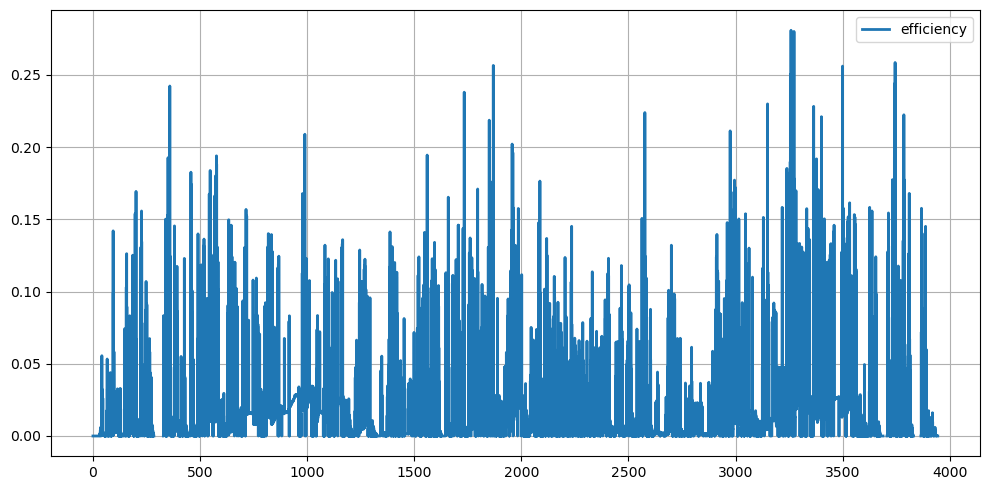

In [7]:
sub = df1.iloc[:50000].copy()

plt.figure(figsize=(10,5))

plt.plot(sub["elapsed_time_s"], sub["chemical_efficiency"], label="efficiency", linewidth=2)

plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [8]:
#df1["chemical_efficiency"].equals(df2["chemical_efficiency"])

### importing 3 datasets

In [9]:
#combining


combined = pd.concat([df1copy, df2copy, df3copy])
combinedLong = pd.concat([df1, df2, df3])

In [10]:
combined.shape

(95277, 11)

In [11]:
combined["chemical_efficiency"] = combinedLong["chemical_efficiency"]
combined = combined.sample(frac=1).reset_index(drop=True)

## eliminating time 

In [23]:
#combined = combined.drop('time', axis=1)
#R = combined.drop('time', axis=1)   # features
R = combined.drop('time', axis=1)
R = R.dropna()
y = R["chemical_efficiency"]
R = R.drop('chemical_efficiency', axis=1)

#R["chemical_efficiency"]= combinedLong["chemical_efficiency"]  
#y = combinedLong['chemical_efficiency']                # label
#del combined['time']
#combined.columns
#combined.shape

In [24]:
R.shape
#combined.columns

(90478, 10)

In [25]:
#print(y)

In [26]:
#print(R)

In [27]:
y_np = y.to_numpy()
R_np = R.to_numpy()

In [17]:
R_np
#y = y.sample(frac=1).reset_index(drop=True)

In [35]:
split = int(0.8 * len(combined))

R_train, R_test = R_np[:split], R_np[split:]
y_train, y_test = y_np[:split], y_np[split:]

#  decoding 
ridge = Ridge(alpha=1e-3, fit_intercept=False)
ridge.fit(R_train, y_train)
y_pred = ridge.predict(R_test)

# MSE
mse = np.mean((y_test - y_pred)**2)
nrmse = np.sqrt(mse / np.var(y_test))

In [36]:
print("ELM–TDM test")
print(f"MSE   = {mse:.4e}")
print(f"NRMSE = {nrmse:.4f}")

ELM–TDM test
MSE   = 3.3356e-04
NRMSE = 0.9026


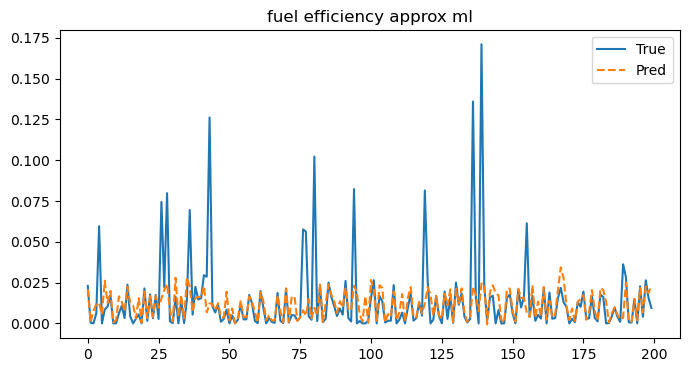

In [33]:
#print(combined[:3])
plt.figure(figsize=(8,4))
plt.plot(y_test[:200], label="True")
plt.plot(y_pred[:200], label="Pred", linestyle="--")
plt.title("fuel efficiency approx ml")
plt.legend()
plt.show()

In [ ]:
array = [1, 5, 3 ,7, 4]
sorted_array = sorted(array)